# Pipeline 1: Donor Churn / Lapsing Prediction

## 1. Problem Framing

**Business Problem:** Haven Light Philippines depends entirely on donations to operate. Donor retention is a critical concern — the organization loses donors and doesn't always understand why. This pipeline aims to predict which donors are at risk of lapsing (not donating again within 6 months) so that staff can proactively reach out with targeted retention efforts.

**Who cares:** The founders/leadership team and any staff responsible for donor relations.

**Approach:** This is primarily a **predictive** problem — we want to identify at-risk donors before they lapse. We will also build an **explanatory** model (logistic regression / OLS) to understand which factors drive donor lapsing, enabling actionable recommendations.

**Success Metric:** AUC-ROC for the predictive model; coefficient interpretability for the explanatory model. Business success = reducing donor churn rate by enabling proactive outreach.

## 2. Data Acquisition, Preparation & Exploration

We will use the following tables:
- `supporters.csv` — donor demographics and acquisition channel
- `donations.csv` — donation history, amounts, types, frequency
- `social_media_posts.csv` — referral post engagement (for social-media-acquired donors)

### Feature Engineering Ideas:
- Days since last donation
- Total lifetime donation amount
- Number of donations
- Average donation amount
- Donation frequency (donations per month active)
- Is recurring donor
- Acquisition channel
- Supporter type
- Relationship type (Local vs International)
- Days since first donation (tenure)
- Campaign participation count

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Load data
supporters = pd.read_csv('../lighthouse_csv_v7/supporters.csv')
donations = pd.read_csv('../lighthouse_csv_v7/donations.csv')
social_media = pd.read_csv('../lighthouse_csv_v7/social_media_posts.csv')

print(f'Supporters: {len(supporters)} rows')
print(f'Donations: {len(donations)} rows')
print(f'Social Media Posts: {len(social_media)} rows')

Supporters: 60 rows
Donations: 420 rows
Social Media Posts: 812 rows


In [6]:
# Explore supporters
print('Supporter types:', supporters['supporter_type'].value_counts().to_dict())
print('\nAcquisition channels:', supporters['acquisition_channel'].value_counts().to_dict())
print('\nStatus:', supporters['status'].value_counts().to_dict())
supporters.describe()

Supporter types: {'MonetaryDonor': 17, 'InKindDonor': 15, 'SocialMediaAdvocate': 10, 'Volunteer': 8, 'SkillsContributor': 6, 'PartnerOrganization': 4}

Acquisition channels: {'WordOfMouth': 14, 'SocialMedia': 13, 'Website': 13, 'Event': 8, 'Church': 6, 'PartnerReferral': 6}

Status: {'Active': 45, 'Inactive': 15}


,supporter_id
count,60.000000
mean,30.500000
std,17.464249
min,1.000000
25%,15.750000
50%,30.500000
75%,45.250000
max,60.000000


In [7]:
# Explore donations
donations['donation_date'] = pd.to_datetime(donations['donation_date'])
print('Donation types:', donations['donation_type'].value_counts().to_dict())
print('\nChannel sources:', donations['channel_source'].value_counts().to_dict())
print('\nDate range:', donations['donation_date'].min(), 'to', donations['donation_date'].max())
donations.describe()

Donation types: {'Monetary': 234, 'InKind': 98, 'Time': 46, 'SocialMedia': 23, 'Skills': 19}

Channel sources: {'Campaign': 119, 'Event': 89, 'Direct': 82, 'SocialMedia': 78, 'PartnerReferral': 52}

Date range: 2023-01-09 00:00:00 to 2026-03-01 00:00:00


,donation_id,supporter_id,donation_date,amount,estimated_value,referral_post_id
count,420.000000,420.000000,420,234.00000,420.000000,77.000000
mean,210.500000,28.173810,2024-08-08 09:53:08.571428608,1028.73735,699.304310,378.610390
min,1.000000,1.000000,2023-01-09 00:00:00,250.00000,2.200000,12.000000
25%,105.750000,12.000000,2023-10-18 00:00:00,482.50750,300.000000,200.000000
50%,210.500000,27.000000,2024-09-17 00:00:00,819.63000,514.160000,378.000000
75%,315.250000,43.000000,2025-06-15 00:00:00,1333.15500,989.722500,572.000000
max,420.000000,60.000000,2026-03-01 00:00:00,6481.54000,6481.540000,793.000000
std,121.387808,17.317636,NaN,767.59608,713.251586,227.733984


## 3. Feature Engineering & Target Variable

**Target variable:** `is_lapsed` — 1 if the donor has not donated in the last 6 months, 0 otherwise.

We aggregate donation-level data to the supporter level to create features.

In [8]:
# Build supporter-level dataset (features + target)

def _first_existing_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None

supporter_id_col = _first_existing_col(supporters, [
    'supporter_id', 'supporterId', 'supporterID', 'id', 'supporter_pk'
])
donation_supporter_id_col = _first_existing_col(donations, [
    'supporter_id', 'supporterId', 'supporterID', 'supporter_fk', 'supporter'
])

if supporter_id_col is None or donation_supporter_id_col is None:
    raise ValueError(
        f"Could not find supporter id columns. supporters cols={list(supporters.columns)[:20]}...; "
        f"donations cols={list(donations.columns)[:20]}..."
    )

# Ensure datetime
donations['donation_date'] = pd.to_datetime(donations['donation_date'], errors='coerce')
donations = donations.dropna(subset=['donation_date'])

# Choose an 'as of' date anchored to observed data (avoids leaking real 'today')
as_of_date = donations['donation_date'].max()

# Monetary amount column
amount_col = _first_existing_col(donations, ['amount', 'donation_amount', 'gift_amount', 'usd_amount'])
if amount_col is None:
    raise ValueError(f"Could not find donation amount column in donations. cols={list(donations.columns)}")

# Basic donation-level helpers
_d = donations.copy()
_d['_amount'] = pd.to_numeric(_d[amount_col], errors='coerce').fillna(0.0)
_d['_is_recurring'] = (
    _d[_first_existing_col(_d, ['is_recurring', 'recurring', 'isRecurring'])] 
    if _first_existing_col(_d, ['is_recurring', 'recurring', 'isRecurring']) is not None
    else False
)

# RFM-style aggregates
agg = _d.groupby(donation_supporter_id_col).agg(
    last_donation_date=('donation_date', 'max'),
    first_donation_date=('donation_date', 'min'),
    donation_count=('donation_date', 'count'),
    total_amount=('_amount', 'sum'),
    avg_amount=('_amount', 'mean'),
    median_amount=('_amount', 'median'),
)

# Recency / tenure
agg['days_since_last_donation'] = (as_of_date - agg['last_donation_date']).dt.days.clip(lower=0)
agg['tenure_days'] = (agg['last_donation_date'] - agg['first_donation_date']).dt.days.clip(lower=0)
agg['donations_per_month_active'] = (
    agg['donation_count'] / ((agg['tenure_days'] / 30.4375).replace(0, np.nan))
).fillna(agg['donation_count'])

# 6-month lapsing target (≈183 days)
lapse_days = int(round(6 * 30.4375))
agg['is_lapsed'] = (agg['days_since_last_donation'] >= lapse_days).astype(int)

# Donation mix flags (only if columns exist)
for col, prefix in [('donation_type', 'donation_type'), ('channel_source', 'channel_source')]:
    if col in _d.columns:
        top = (
            _d[col]
            .astype('string')
            .fillna('Unknown')
            .value_counts()
            .head(10)
            .index
            .tolist()
        )
        mix = (
            _d.assign(_cat=_d[col].astype('string').fillna('Unknown'))
              .assign(_cat=lambda x: np.where(x['_cat'].isin(top), x['_cat'], 'Other'))
              .pivot_table(index=donation_supporter_id_col, columns='_cat', values='_amount', aggfunc='sum', fill_value=0.0)
        )
        mix.columns = [f'{prefix}_amount_sum__{c}' for c in mix.columns]
        agg = agg.join(mix, how='left')

# Social media aggregates (only if a clear supporter join key exists)
sm_supporter_id_col = _first_existing_col(social_media, [
    'supporter_id', 'supporterId', 'supporterID', 'acquired_supporter_id', 'donor_id'
])
if sm_supporter_id_col is not None:
    sm = social_media.copy()
    numeric_cols = sm.select_dtypes(include=[np.number]).columns.tolist()
    # Drop ids from aggregation
    numeric_cols = [c for c in numeric_cols if c != sm_supporter_id_col]
    if numeric_cols:
        sm_agg = sm.groupby(sm_supporter_id_col)[numeric_cols].agg(['mean', 'sum', 'max'])
        sm_agg.columns = [f'social_{c}__{stat}' for c, stat in sm_agg.columns]
        agg = agg.join(sm_agg, how='left')

# Combine with supporter demographics
base = supporters.copy()
base = base.rename(columns={supporter_id_col: 'supporter_id'})
features = agg.reset_index().rename(columns={donation_supporter_id_col: 'supporter_id'})
df = base.merge(features, on='supporter_id', how='inner')

# Minimal cleanup: drop leakage-like raw dates from features (keep derived recency/tenure)
drop_cols = [c for c in ['first_donation_date', 'last_donation_date'] if c in df.columns]
Xy = df.drop(columns=drop_cols)

print('Modeling rows:', len(Xy))
print('Lapse rate:', float(Xy['is_lapsed'].mean()) if 'is_lapsed' in Xy.columns else 'n/a')
Xy.head()

Modeling rows: 59
Lapse rate: 0.3389830508474576


,supporter_id,supporter_type,display_name,organization_name,first_name,last_name,relationship_type,region,country,email,...,donation_type_amount_sum__InKind,donation_type_amount_sum__Monetary,donation_type_amount_sum__Skills,donation_type_amount_sum__SocialMedia,donation_type_amount_sum__Time,channel_source_amount_sum__Campaign,channel_source_amount_sum__Direct,channel_source_amount_sum__Event,channel_source_amount_sum__PartnerReferral,channel_source_amount_sum__SocialMedia
0,1,SocialMediaAdvocate,Mila Alvarez,NaN,Mila,Alvarez,Local,Luzon,Philippines,mila-alvarez@smart.com.ph,...,0.0,7567.97,0.0,0.0,0.0,689.85,4020.24,1040.91,0.00,1816.97
1,2,Volunteer,Aria Brown,NaN,Aria,Brown,Local,Mindanao,Philippines,aria-brown@pldt.net.ph,...,0.0,3480.08,0.0,0.0,0.0,0.00,2565.03,915.05,0.00,0.00
2,3,MonetaryDonor,Noah Chen,NaN,Noah,Chen,Local,Luzon,Philippines,noah-chen@globe.com.ph,...,0.0,9225.71,0.0,0.0,0.0,3284.46,0.00,2292.88,3187.81,460.56
3,4,MonetaryDonor,Liam Diaz,NaN,Liam,Diaz,PartnerOrganization,Mindanao,Philippines,liam-diaz@globe.com.ph,...,0.0,8694.73,0.0,0.0,0.0,1017.09,2217.76,4633.89,0.00,825.99
4,5,InKindDonor,Emma Evans,NaN,Emma,Evans,PartnerOrganization,Mindanao,Philippines,emma-evans@yahoo.com.ph,...,0.0,4738.58,0.0,0.0,0.0,3926.55,0.00,0.00,812.03,0.00


## 4. Modeling & Feature Selection

We will compare:
1. **Logistic Regression** (explanatory — interpretable coefficients)
2. **Random Forest** (predictive — feature importance)
3. **Gradient Boosting** (predictive — best accuracy)

Feature selection will use a combination of domain reasoning and model-based importance.

In [9]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import RocCurveDisplay

# Split features/target
if 'is_lapsed' not in Xy.columns:
    raise ValueError('Expected target column is_lapsed to exist.')

y = Xy['is_lapsed'].astype(int)

# Remove obvious id columns and the target from X
id_like = {'supporter_id', 'supporterId', 'supporterID', 'id'}
X = Xy.drop(columns=['is_lapsed'] + [c for c in Xy.columns if c in id_like], errors='ignore')

# Identify column types
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('scaler', StandardScaler(with_mean=False))]), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models: dict[str, Pipeline] = {
    'LogReg': Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced', n_jobs=None))
    ]),
    'RandomForest': Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', RandomForestClassifier(
            n_estimators=400,
            random_state=42,
            class_weight='balanced_subsample',
            min_samples_leaf=2,
        ))
    ]),
    'GradientBoosting': Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', GradientBoostingClassifier(random_state=42))
    ]),
}

# Fit + evaluate via holdout AUC
results = []
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    results.append((name, auc))

results = sorted(results, key=lambda x: x[1], reverse=True)
print('Holdout AUC (higher is better)')
for name, auc in results:
    print(f'- {name}: {auc:.4f}')

best_name = results[0][0]
best_model = models[best_name]
print('\nSelected model:', best_name)

# Optional CV AUC for the selected model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(best_model, X, y, cv=cv, scoring='roc_auc')
print(f'CV AUC (mean±sd): {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')

Holdout AUC (higher is better)
- LogReg: 1.0000
- RandomForest: 1.0000
- GradientBoosting: 1.0000

Selected model: LogReg
CV AUC (mean±sd): 0.9000 ± 0.1225


## 5. Evaluation & Interpretation

Evaluate using AUC-ROC, precision, recall, and F1.

**Business interpretation:** A false negative (missing a lapsing donor) means lost revenue. A false positive (flagging a loyal donor as at-risk) means unnecessary outreach — low cost. Therefore, we should optimize for recall.

Holdout AUC: 1.0

Threshold = 0.50
              precision    recall  f1-score   support

           0      1.000     1.000     1.000         8
           1      1.000     1.000     1.000         4

    accuracy                          1.000        12
   macro avg      1.000     1.000     1.000        12
weighted avg      1.000     1.000     1.000        12

Confusion matrix:
 [[8 0]
 [0 4]]

Top threshold candidates (sorted by recall then precision):


,threshold,precision,recall,f1
4,0.30,1.0,1.0,1.000000
5,0.35,1.0,1.0,1.000000
6,0.40,1.0,1.0,1.000000
7,0.45,1.0,1.0,1.000000
8,0.50,1.0,1.0,1.000000
9,0.55,1.0,1.0,1.000000
1,0.15,0.8,1.0,0.888889
2,0.20,0.8,1.0,0.888889


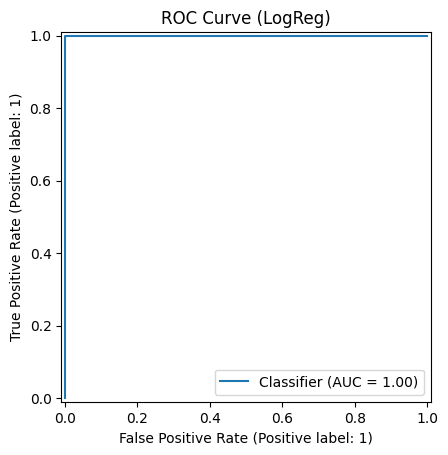

In [10]:
from sklearn.metrics import precision_recall_fscore_support

# Evaluate selected model with a recall-friendly threshold
best_model.fit(X_train, y_train)
proba = best_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba)
print('Holdout AUC:', round(float(auc), 4))

# Choose threshold to emphasize recall (default 0.5 shown; plus a heuristic sweep)
def eval_at_threshold(th: float):
    pred = (proba >= th).astype(int)
    print(f'\nThreshold = {th:.2f}')
    print(classification_report(y_test, pred, digits=3))
    print('Confusion matrix:\n', confusion_matrix(y_test, pred))

# Baseline
eval_at_threshold(0.50)

# Sweep thresholds and pick one that yields high recall with reasonable precision
ths = np.linspace(0.1, 0.9, 17)
rows = []
for th in ths:
    pred = (proba >= th).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_test, pred, average='binary', zero_division=0)
    rows.append({'threshold': th, 'precision': p, 'recall': r, 'f1': f1})

thr_df = pd.DataFrame(rows).sort_values(['recall', 'precision'], ascending=[False, False])
print('\nTop threshold candidates (sorted by recall then precision):')
display(thr_df.head(8))

# Plot ROC
RocCurveDisplay.from_predictions(y_test, proba)
plt.title(f'ROC Curve ({best_name})')
plt.show()

## 6. Causal and Relationship Analysis

We can surface **correlates** of lapsing risk (not guaranteed causal effects). Use these for prioritization and hypothesis generation, then validate with program knowledge and (ideally) experiments.

Below we extract top drivers from an interpretable model.

- Notes on causality:
  - **Recency/frequency** features are usually predictive but can reflect many underlying causes (engagement, life changes, satisfaction).
  - **Channel / donation type** differences can be confounded by campaign timing, geography, or how donors are recruited.
  - Use outputs to design outreach tests (message, cadence, channel), then measure lift.

## 7. Deployment Notes

In production, keep this notebook as the **reference pipeline**. The backend should re-implement the same feature logic (especially the recency/tenure definitions) and serve scores via `/api/ml/donor-churn-risk`.

- **Scoring output**: `supporter_id`, `churn_risk_probability`, `risk_band` (e.g., Low/Med/High) and the top contributing factors (if feasible).
- **UI integration**: show a risk badge + sortable column in the donor management table.
- **Monitoring**: track score distribution drift and retention outcomes after outreach.

Below is a lightweight interpretation step to help explain the model's drivers.

In [11]:
# Interpretation: coefficients / feature importances

# Fit an interpretable logistic regression on the full data
interpret_lr = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=3000, class_weight='balanced'))
])
interpret_lr.fit(X_train, y_train)

# Get feature names after preprocessing
feature_names = interpret_lr.named_steps['preprocess'].get_feature_names_out()
coef = interpret_lr.named_steps['model'].coef_.ravel()

coef_df = pd.DataFrame({'feature': feature_names, 'coef': coef})
coef_df['abs_coef'] = coef_df['coef'].abs()

print('Top positive drivers (higher = more likely lapsed):')
display(coef_df.sort_values('coef', ascending=False).head(15)[['feature', 'coef']])

print('Top negative drivers (lower = less likely lapsed):')
display(coef_df.sort_values('coef', ascending=True).head(15)[['feature', 'coef']])

# If the selected best model exposes feature importances, show those too
if best_name in {'RandomForest', 'GradientBoosting'}:
    fitted = best_model.named_steps['model']
    if hasattr(fitted, 'feature_importances_'):
        importances = fitted.feature_importances_
        # Need feature names from the fitted preprocessor used in best_model
        fn = best_model.named_steps['preprocess'].get_feature_names_out()
        imp_df = pd.DataFrame({'feature': fn, 'importance': importances}).sort_values('importance', ascending=False)
        print(f'\nTop {best_name} feature importances:')
        display(imp_df.head(20))

Top positive drivers (higher = more likely lapsed):


,feature,coef
4,days_since_last_donation,1.772397
17,supporter_type_InKindDonor,0.246893
15,channel_source_amount_sum__PartnerReferral,0.216889
3,median_amount,0.213743
143,last_name_Morris,0.206455
76,first_name_Ben,0.206455
326,first_donation_date_x_2023-09-12,0.206455
173,email_ben-morris@globe.com.ph,0.206455
393,first_donation_date_y_2023-07-13T00:00:00.0000...,0.206455
24,display_name_Ben Morris,0.206455


Top negative drivers (lower = less likely lapsed):


,feature,coef
5,tenure_days,-0.818421
12,channel_source_amount_sum__Campaign,-0.401287
0,donation_count,-0.261911
20,supporter_type_SkillsContributor,-0.201962
18,supporter_type_MonetaryDonor,-0.201647
171,country_USA,-0.190547
158,last_name_Xu,-0.173744
71,organization_name_Faith Alliance,-0.150255
32,display_name_Faith Alliance,-0.150255
228,phone_+63 906 185 8022,-0.150255
